In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
cmap = plt.get_cmap('Dark2')

In [2]:
N = range(10)
colors = [cmap(i) for i in N]

Residual Formula: $$\text{res}=\dfrac{G_{\text{wi2easy}}-G_{\text{SWIM}}}{G_{\text{wi2easy}}}$$ at $Q_{\text{wi2easy}}$

In [3]:
def residual_calc (Q1,GQ1,Q2,GQ2):
    cs2  = CubicSpline(np.log10(Q2),np.log10(GQ2))

    # (GQ1-GQ2)/GQ1
    res = np.subtract(GQ1,10**(cs2(np.log10(Q1))))/GQ1
    return Q1,res

$$V= \dfrac{V_0}{4}\phi^4$$ $$\Upsilon = C_{\Upsilon}\dfrac{T^3}{\phi^2}$$

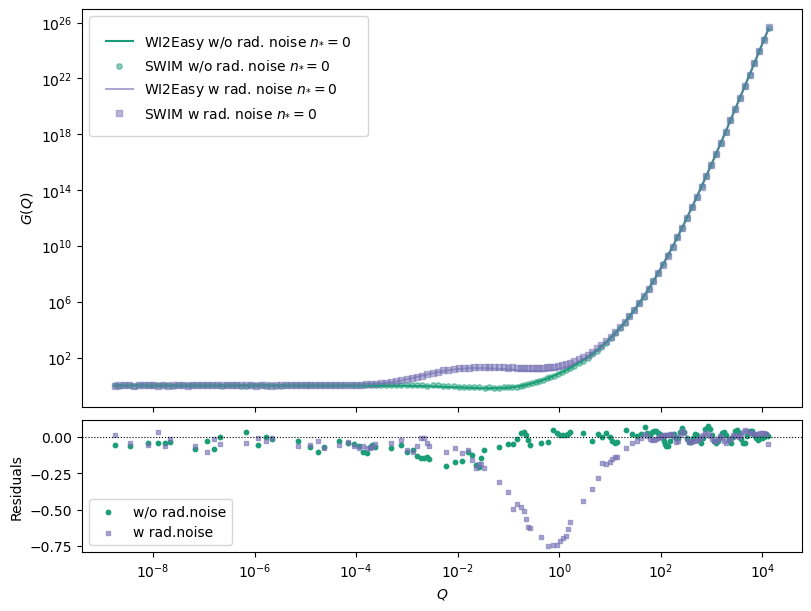

In [5]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Quartic/T3ph2/no_rad_noise_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Quartic/T3ph2/no_rad_noise_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Quartic/T3ph2/rad_noise_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Quartic/T3ph2/rad_noise_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Quartic_T3ph2_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

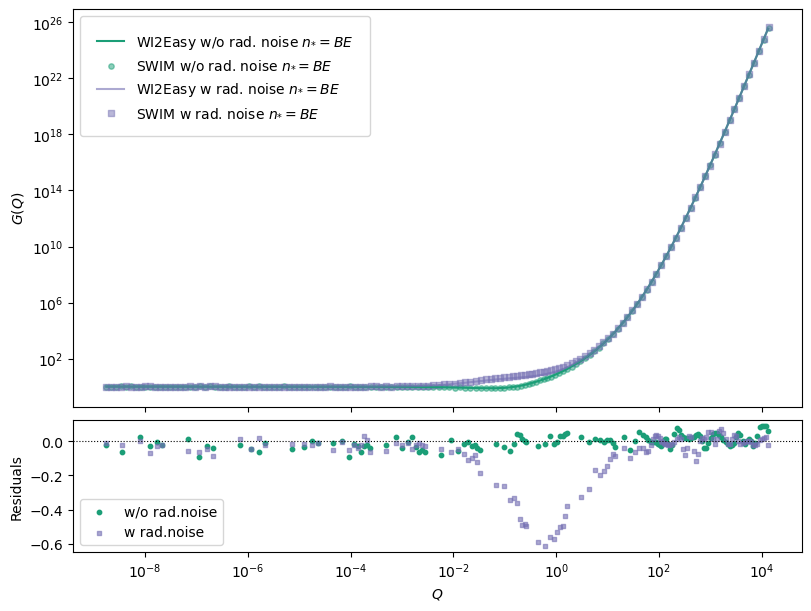

In [6]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Quartic/T3ph2/no_rad_noise_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Quartic/T3ph2/no_rad_noise_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Quartic/T3ph2/rad_noise_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Quartic/T3ph2/rad_noise_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = BE$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = BE$")

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = BE$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = BE$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Quartic_T3ph2_BE.png",dpi=300,bbox_inches='tight')
plt.show()

$$V= \dfrac{V_0}{4}\phi^4$$ $$\Upsilon = C_{\Upsilon}T^3$$

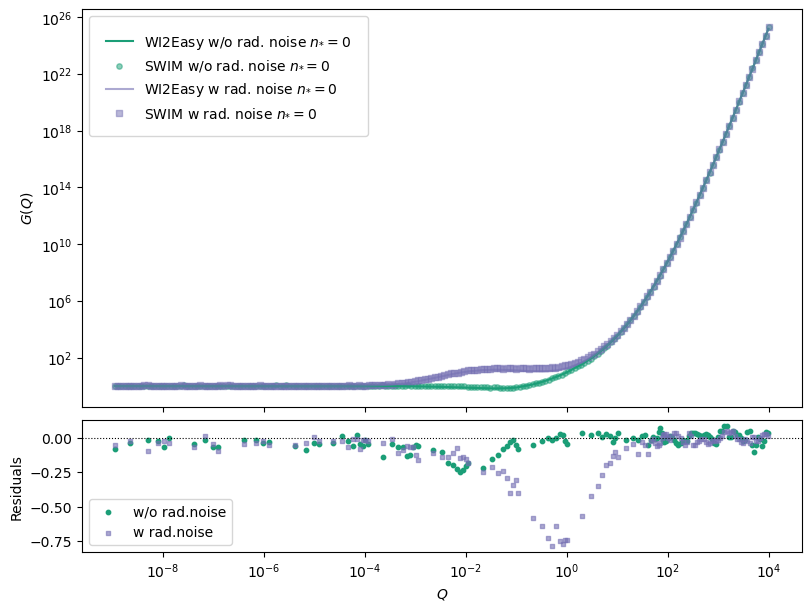

In [13]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Quartic/T3/no_rad_noise_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Quartic/T3/no_rad_noise_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Quartic/T3/rad_noise_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Quartic/T3/rad_noise_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Quartic_T3_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

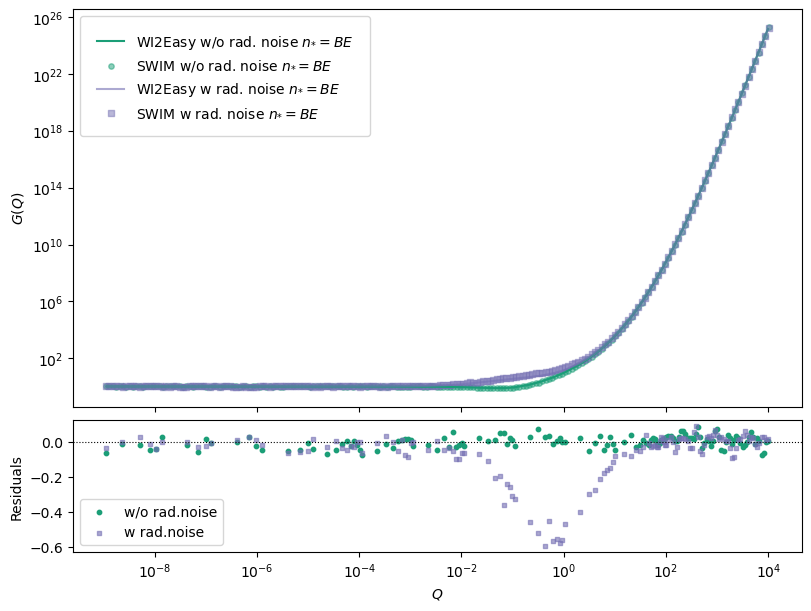

In [14]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Quartic/T3/no_rad_noise_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Quartic/T3/no_rad_noise_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Quartic/T3/rad_noise_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Quartic/T3/rad_noise_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = BE$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = BE$")

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = BE$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = BE$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Quartic_T3_BE.png",dpi=300,bbox_inches='tight')
plt.show()

$$V= \dfrac{V_0}{4}\phi^4$$ $$\Upsilon = C_{\Upsilon}T$$

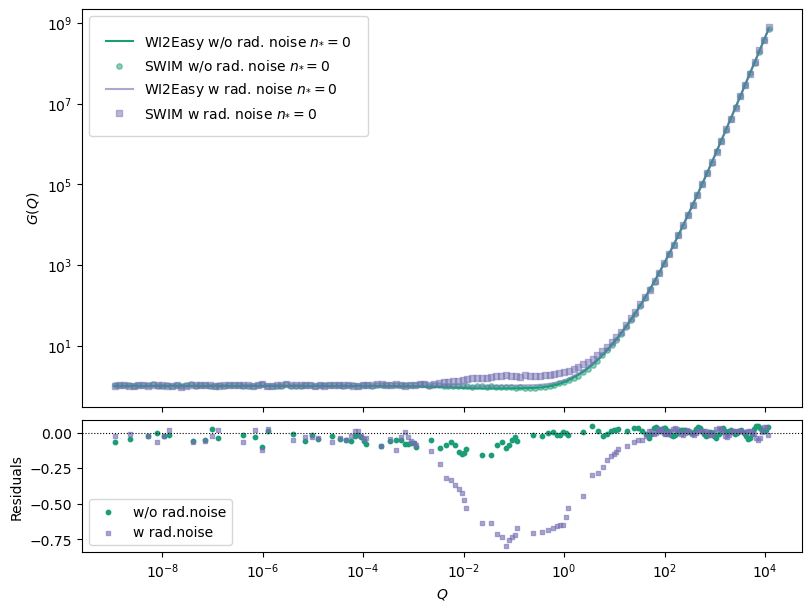

In [15]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Quartic/T/no_rad_noise_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Quartic/T/no_rad_noise_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Quartic/T/rad_noise_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Quartic/T/rad_noise_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Quartic_T_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

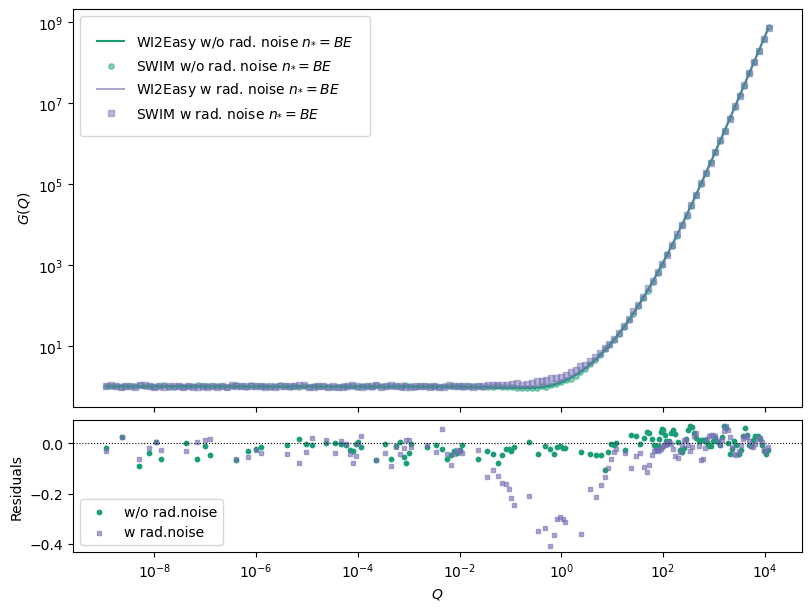

In [16]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Quartic/T/no_rad_noise_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Quartic/T/no_rad_noise_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Quartic/T/rad_noise_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Quartic/T/rad_noise_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = BE$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = BE$")

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = BE$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = BE$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Quartic_T_BE.png",dpi=300,bbox_inches='tight')
plt.show()

$$V_0\left[F -4e^{-\frac{\phi}{\sqrt{3}}} + e^{-4\frac{\phi}{\sqrt{3}}} + R \left(e^{2\frac{\phi}{\sqrt{3}}}-1\right)\right]$$
$$\Upsilon = C_{\Upsilon}T^3$$

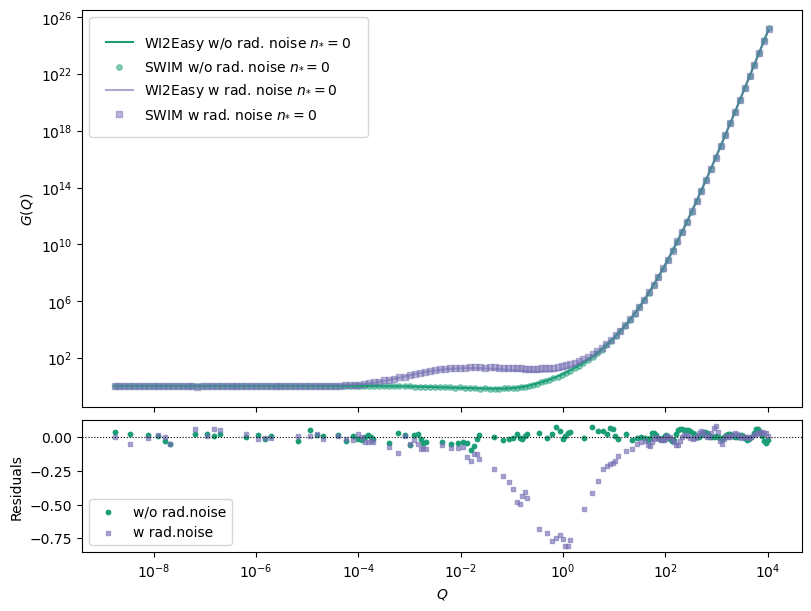

In [17]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Fibre-i/T3/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Fibre-i/T3/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Fibre-i/T3/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Fibre-i/T3/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Fibre_i_T3_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

$$V_0\left[F -4e^{-\frac{\phi}{\sqrt{3}}} + e^{-4\frac{\phi}{\sqrt{3}}} + R \left(e^{2\frac{\phi}{\sqrt{3}}}-1\right)\right]$$
$$\Upsilon = C_{\Upsilon}T$$

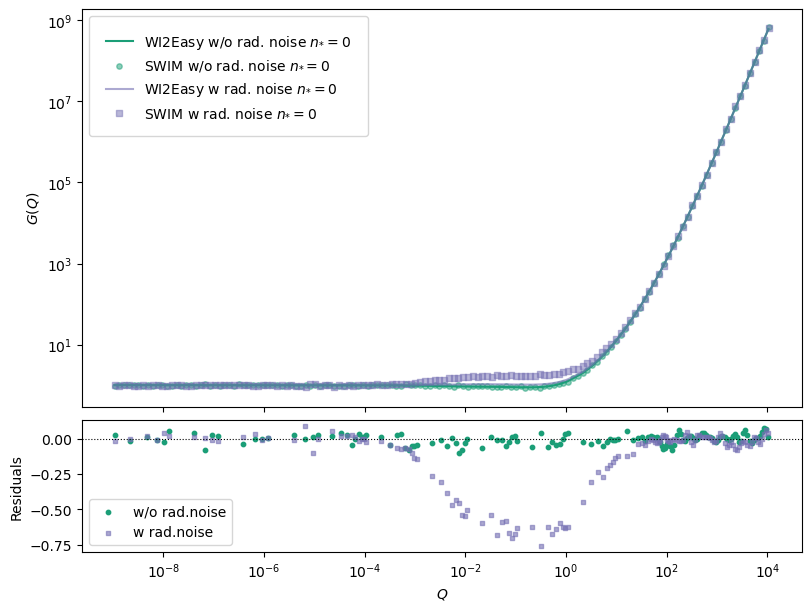

In [18]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Fibre-i/T/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Fibre-i/T/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Fibre-i/T/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Fibre-i/T/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Fibre_i_T_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

$$V_0 \left[1+\cos\left(\dfrac{\phi}{f}\right)\right]$$
$$\Upsilon = C_{\Upsilon}T^3$$

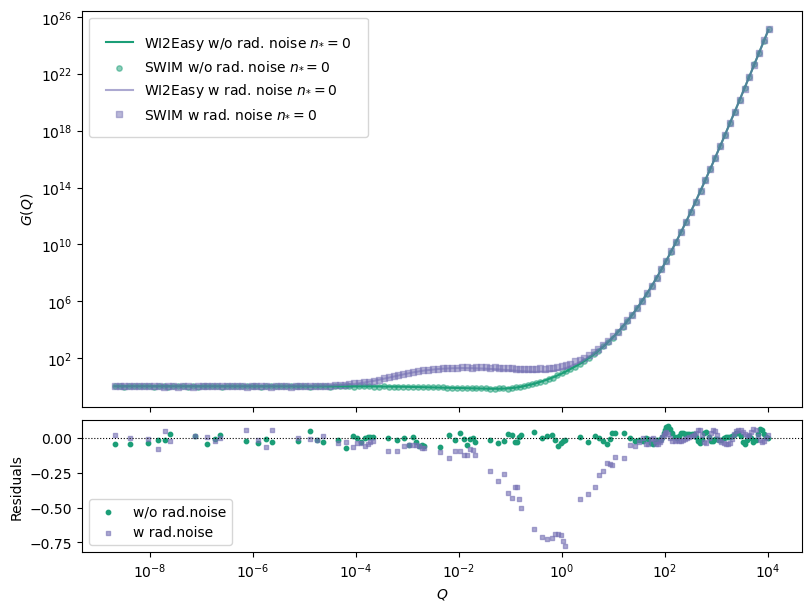

In [19]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Axion/T3/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Axion/T3/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Axion/T3/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Axion/T3/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Axion_T3_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

$$V_0 \left[1+\cos\left(\dfrac{\phi}{f}\right)\right]$$
$$\Upsilon = C_{\Upsilon}T$$

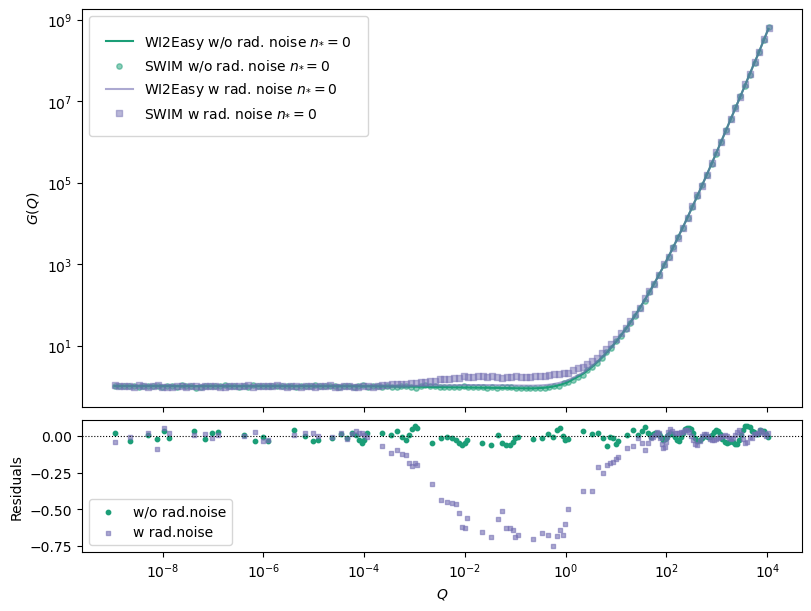

In [20]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Axion/T/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Axion/T/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Axion/T/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Axion/T/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Axion_T_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

$$V_0\left[1 - \gamma (\phi)^2\right]$$
$$\Upsilon = C_{\Upsilon}T^3$$

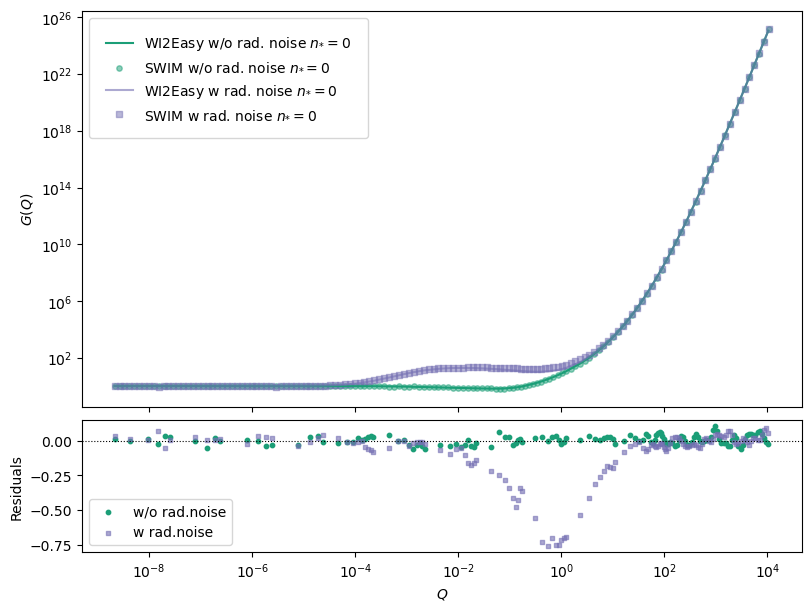

In [21]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Hilltop/T3/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Hilltop/T3/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Hilltop/T3/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Hilltop/T3/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Hilltop_T3_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

$$V_0\left[1 - \gamma (\phi)^2\right]$$
$$\Upsilon = C_{\Upsilon}T$$

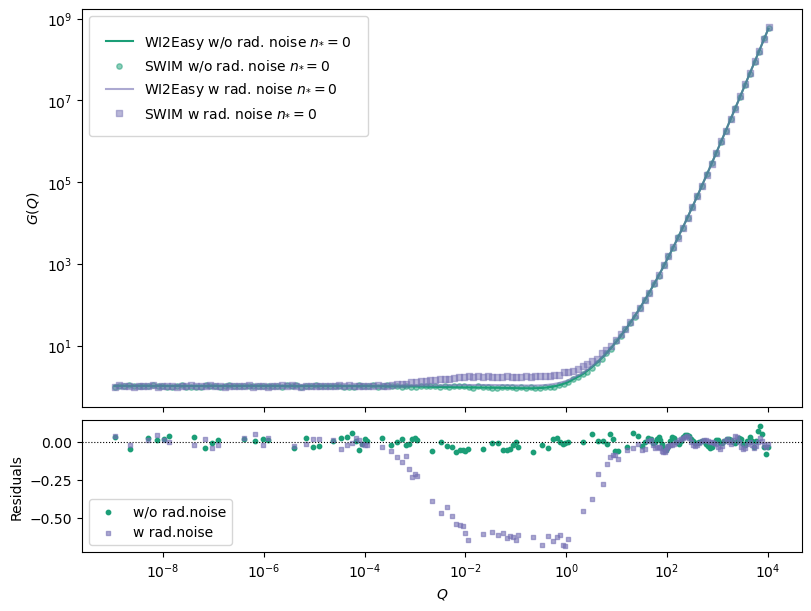

In [22]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Hilltop/T/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Hilltop/T/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Hilltop/T/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Hilltop/T/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Hilltop_T_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

$$\dfrac{M^4}{4\lambda} + \dfrac{V_0}{2}\phi^2$$
$$\Upsilon = C_{\Upsilon}T^3$$

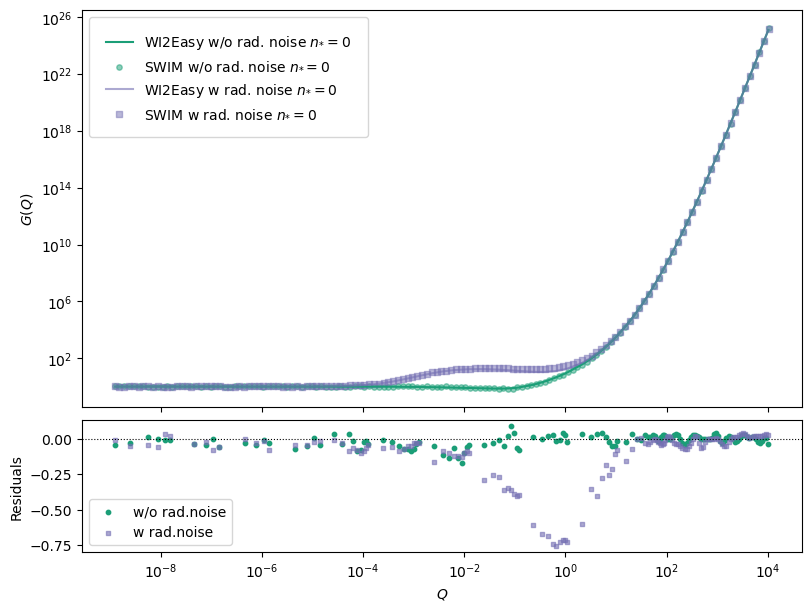

In [23]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Hybrid/T3/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Hybrid/T3/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Hybrid/T3/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Hybrid/T3/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Hybrid_T3_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

$$V = \dfrac{M^4}{4\lambda} + \dfrac{V_0}{2}\phi^2$$
$$\Upsilon = C_{\Upsilon}T$$

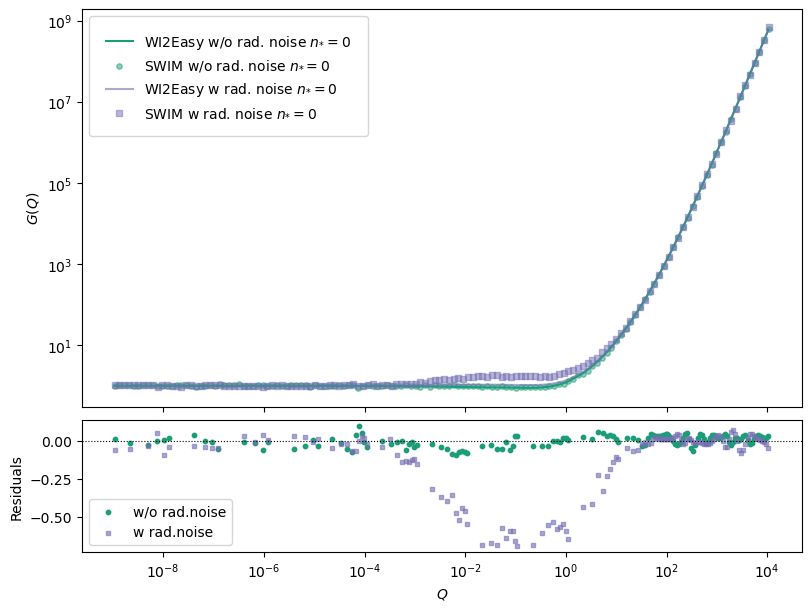

In [24]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Hybrid/T/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Hybrid/T/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Hybrid/T/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Hybrid/T/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Hybrid_T_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

$$V = V_0 e^{-\alpha \phi^n}$$
$$\Upsilon = C_{\Upsilon}T^3$$
$$n=2$$

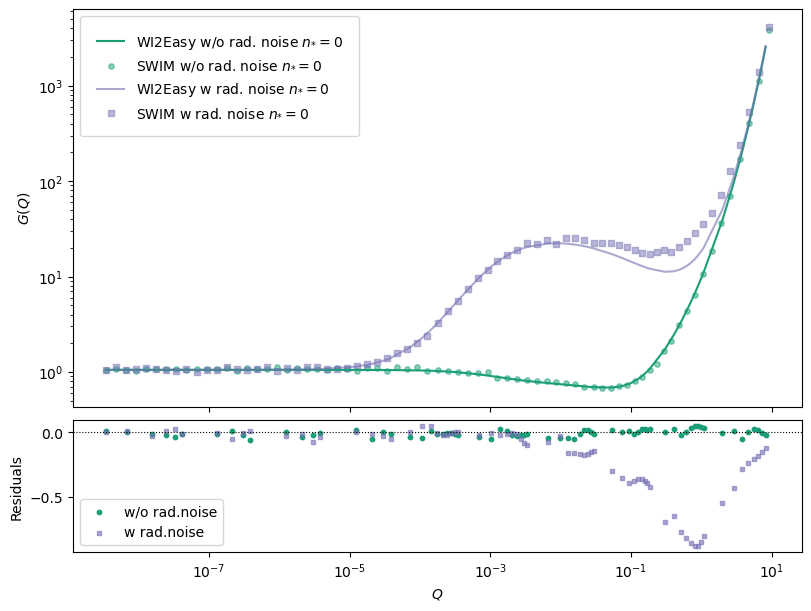

In [25]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Exponential_n2/Weak/T3/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Exponential_n2/Weak/T3/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Exponential_n2/Weak/T3/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Exponential_n2/Weak/T3/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Exponential_T3_noBE_n2_weak.png",dpi=300,bbox_inches='tight')
plt.show()

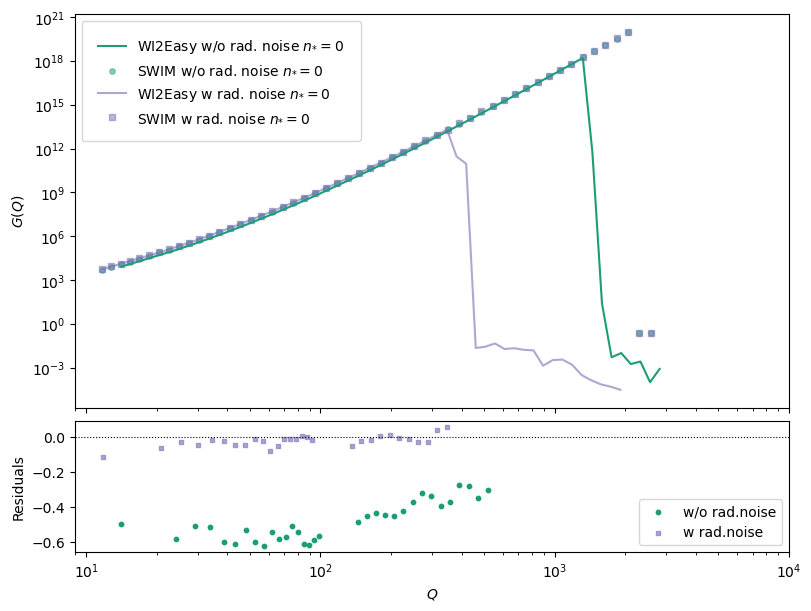

In [26]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Exponential_n2/Strong/T3/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Exponential_n2/Strong/T3/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Exponential_n2/Strong/T3/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Exponential_n2/Strong/T3/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres[0:-18], Gres[0:-18], color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r[0:-18], Gres_r[0:-18], color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
plt.xticks([1e1,1e2,1e3,1e4])
# plt.savefig("Exponential_T3_noBE_n2_strong.png",dpi=300,bbox_inches='tight')
plt.show()

$$V = V_0 e^{-\alpha \phi^n}$$
$$\Upsilon = C_{\Upsilon}T^3$$
$$n=3$$

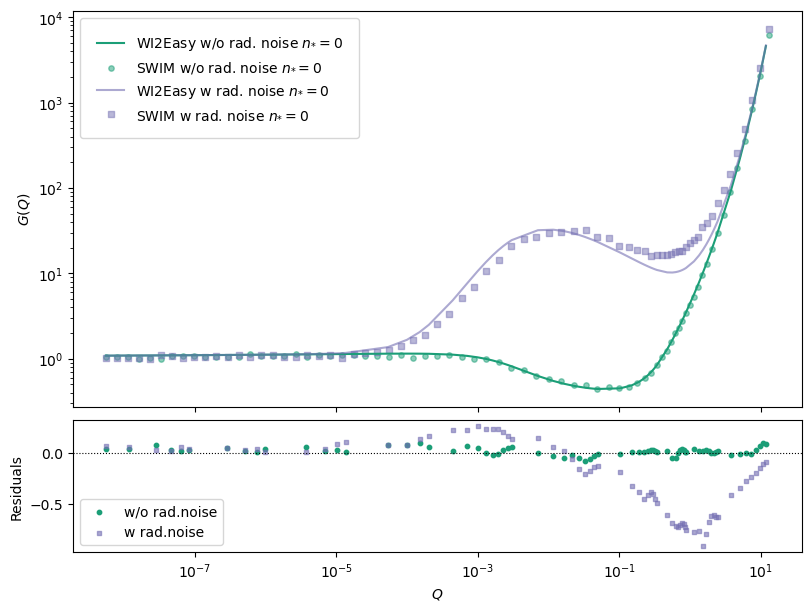

In [27]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Exponential_n3/Weak/T3/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Exponential_n3/Weak/T3/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Exponential_n3/Weak/T3/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Exponential_n3/Weak/T3/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Exponential_T3_noBE_n3_weak.png",dpi=300,bbox_inches='tight')
plt.show()

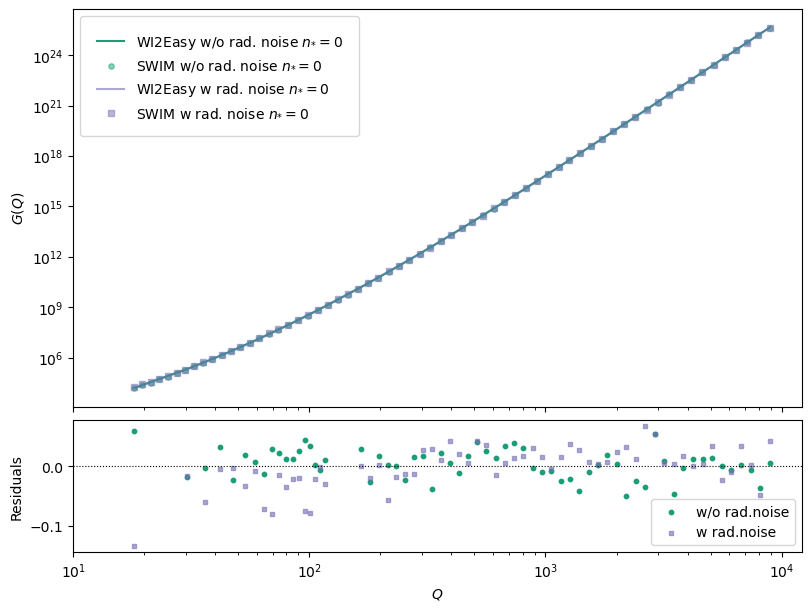

In [28]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Exponential_n3/Strong/T3/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Exponential_n3/Strong/T3/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Exponential_n3/Strong/T3/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Exponential_n3/Strong/T3/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
plt.xticks([1e1,1e2,1e3,1e4])
# plt.savefig("Exponential_T3_noBE_n3_strong.png",dpi=300,bbox_inches='tight')
plt.show()

$$V = \dfrac{V_0}{2}\phi^2$$
$$\Upsilon = C_\Upsilon g^4 \dfrac{M^2 T^2}{m_{\chi}^3} \left[1+ \dfrac{1}{\sqrt{2\pi}}\left(\dfrac{m_{\chi}}{T}\right)^{3/2}\right]e^{-m_{\chi}/T}$$

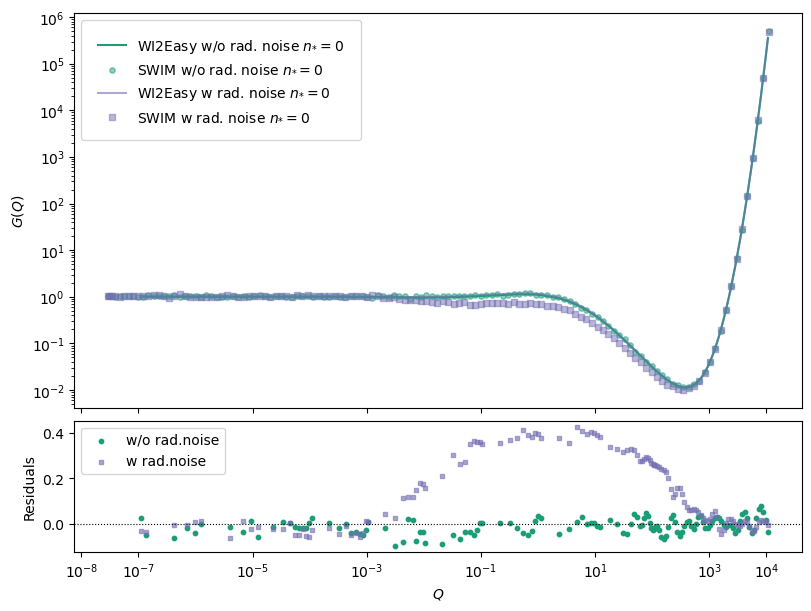

In [29]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Quadratic/EFT/no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Quadratic/EFT/no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Quadratic/EFT/rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Quadratic/EFT/rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
plt.xticks([1e-8,1e-7,1e-5,1e-3,1e-1,1e1,1e3,1e4])
#plt.tight_layout()
# plt.savefig("Quadratic_EFT_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

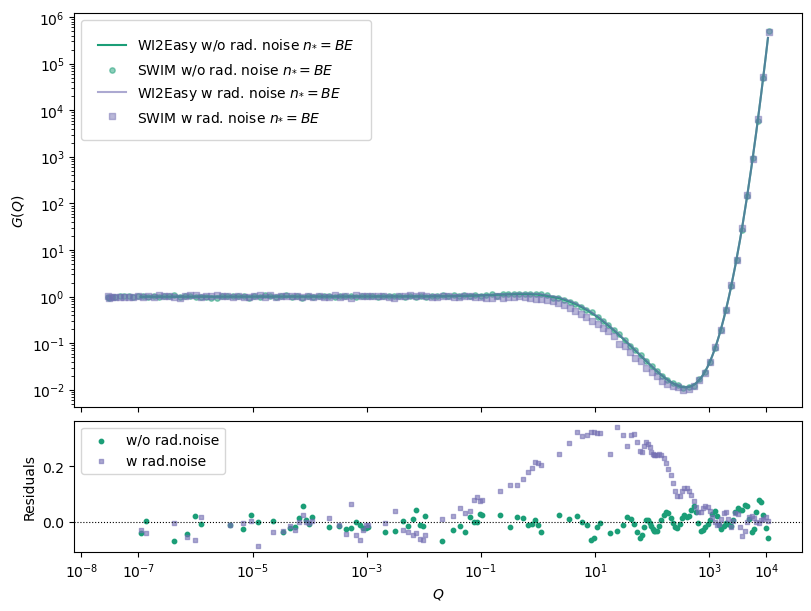

In [30]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Quadratic/EFT/no_rad_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Quadratic/EFT/no_rad_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Quadratic/EFT/rad_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Quadratic/EFT/rad_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = BE$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = BE$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = BE$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = BE$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
plt.xticks([1e-8,1e-7,1e-5,1e-3,1e-1,1e1,1e3,1e4])
#plt.tight_layout()
# plt.savefig("Quadratic_EFT_BE.png",dpi=300,bbox_inches='tight')
plt.show()

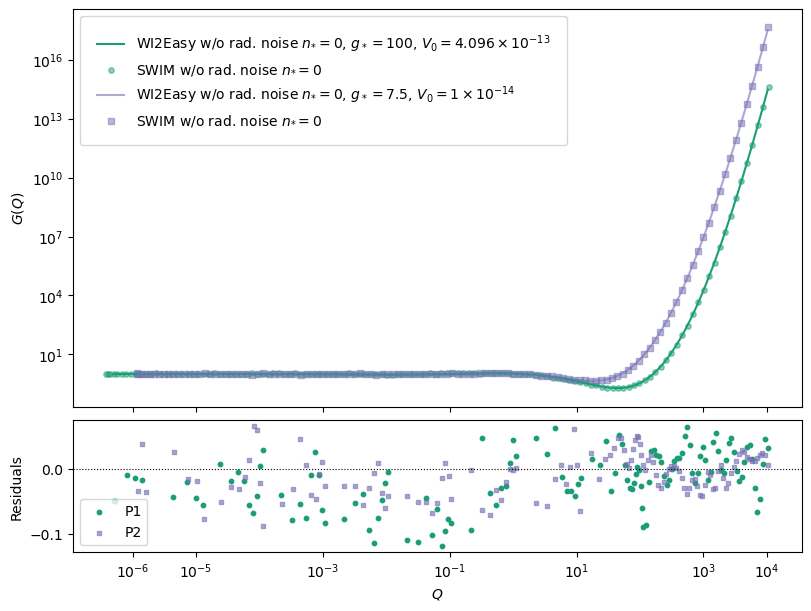

In [31]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Quadratic/EFT/g100_no_rad_no_therm/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Quadratic/EFT/g100_no_rad_no_therm/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Quadratic/EFT/V0_1e-14_no_rad_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Quadratic/EFT/V0_1e-14_no_rad_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$, $g_* = 100$, $V_0 = 4.096 \times 10^{-13}$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w/o rad. noise $n_{*} = 0$, $g_* = 7.5$, $V_0 = 1 \times 10^{-14}$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label=r'P1',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label=r'P2',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend(loc="lower left")
plt.xticks([1e-6,1e-5,1e-3,1e-1,1e1,1e3,1e4])
#plt.tight_layout()
# plt.savefig("Quadratic_EFT_g100_V04e-13.png",dpi=300,bbox_inches='tight')
plt.show()

$$V(\phi) = V_0 \phi^4$$
$$\Upsilon_{\mathrm{eff}} = C_{\Upsilon} \left(\dfrac{C_T T^3}{1 + \dfrac{4\tilde{N_f}C_T T}{H N_c}}\right)$$

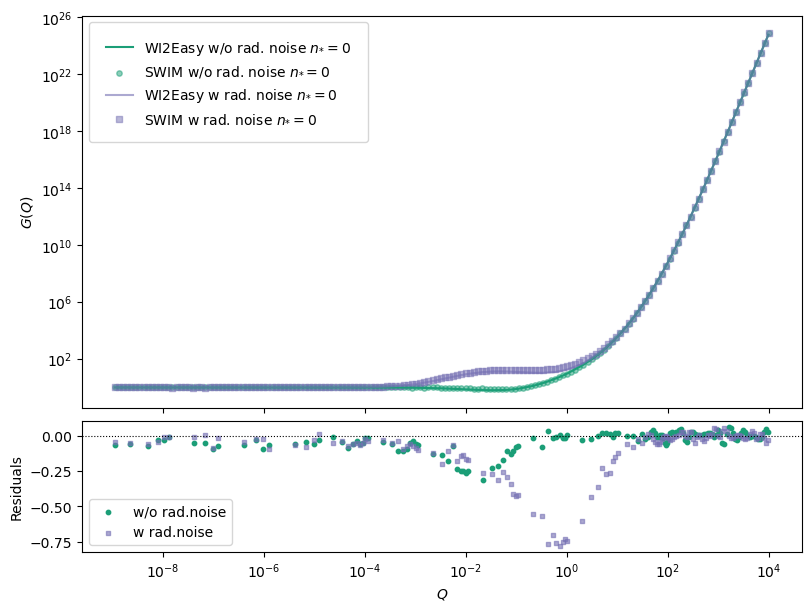

In [32]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Quartic/Standard_Model/no_rad_noise_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Quartic/Standard_Model/no_rad_noise_no_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Quartic/Standard_Model/rad_noise_no_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Quartic/Standard_Model/rad_noise_no_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = 0$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = 0$",)

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = 0$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = 0$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Quartic_SM_noBE.png",dpi=300,bbox_inches='tight')
plt.show()

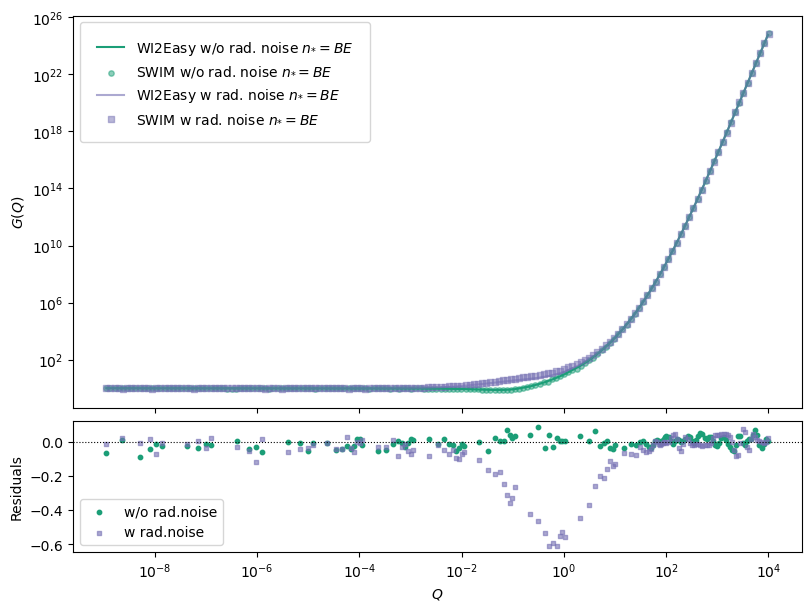

In [33]:
#Load files
Q_WI2easy,G_WI2easy = np.loadtxt("Quartic/Standard_Model/no_rad_noise_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM,G_SWIM = np.loadtxt("Quartic/Standard_Model/no_rad_noise_thermalize/GQ.dat",unpack=True,delimiter=",")

Q_WI2easy_r,G_WI2easy_r = np.loadtxt("Quartic/Standard_Model/rad_noise_thermalize/GQ_wi2easy.dat",unpack=True)
Q_SWIM_r,G_SWIM_r = np.loadtxt("Quartic/Standard_Model/rad_noise_thermalize/GQ.dat",unpack=True,delimiter=",")


#Code for residuals
Qres,Gres = residual_calc(Q_WI2easy,G_WI2easy,Q_SWIM,G_SWIM)
Qres_r,Gres_r= residual_calc(Q_WI2easy_r,G_WI2easy_r,Q_SWIM_r,G_SWIM_r)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               figsize=(8, 6),constrained_layout=True)
ax1.plot(Q_WI2easy,G_WI2easy,color=colors[0],label=r"WI2Easy w/o rad. noise $n_{*} = BE$")
ax1.scatter(Q_SWIM,G_SWIM,color=colors[0],alpha=0.5,s=15,label=r"SWIM w/o rad. noise $n_{*} = BE$")

ax1.plot(Q_WI2easy_r,G_WI2easy_r,color=colors[2],label=r"WI2Easy w rad. noise $n_{*} = BE$",alpha=0.6)
ax1.scatter(Q_SWIM_r,G_SWIM_r,color=colors[2],alpha=0.5,s=15,label=r"SWIM w rad. noise $n_{*} = BE$",marker='s')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel("$G(Q)$")
ax1.legend(borderpad=1.2)
ax2.scatter(Qres, Gres, color=colors[0], label='w/o rad.noise',s=10)
ax2.scatter(Qres_r, Gres_r, color=colors[2], label='w rad.noise',s=10,alpha=0.6,marker='s')
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')  # horizontal reference line
ax2.set_xscale('log')
ax2.set_xlabel("$Q$")
ax2.set_ylabel("Residuals")
ax2.legend()
#plt.tight_layout()
# plt.savefig("Quartic_SM_BE.png",dpi=300,bbox_inches='tight')
plt.show()